In [1]:
!nvidia-smi

Fri Oct  3 09:04:06 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             25W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

<h1>Imports</h1>

In [2]:
!pip install bitsandbytes accelerate transformers peft --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 29.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.4 MB/s eta 0:00:00:00:0100:01


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
import torch
import gc
import os

warnings.filterwarnings('ignore')
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# CRITICAL: Clear everything first
torch.cuda.empty_cache()
gc.collect()

30

<h1>Data Loading</h1>

In [4]:
df = pd.read_csv('/kaggle/input/map-charting-student-math-misunderstandings/train.csv')
print(f"Dataset shape: {df.shape}")
df


Dataset shape: (36696, 7)


,row_id,QuestionId,QuestionText,MC_Answer,StudentExplanation,Category,Misconception
0,0,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),0ne third is equal to tree nineth,True_Correct,NaN
1,1,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),1 / 3 because 6 over 9 is 2 thirds and 1 third...,True_Correct,NaN
2,2,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),"1 3rd is half of 3 6th, so it is simplee to un...",True_Neither,NaN
3,3,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),1 goes into everything and 3 goes into nine,True_Neither,NaN
4,4,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),1 out of every 3 isn't coloured,True_Correct,NaN
...,...,...,...,...,...,...,...
36691,36691,109465,The probability of an event occurring is \( 0....,Unlikely,very unlikely.,False_Neither,NaN
36692,36692,109465,The probability of an event occurring is \( 0....,Unlikely,yea pretty much unlikely from what it seems.,False_Neither,NaN
36693,36693,109465,The probability of an event occurring is \( 0....,Unlikely,yeah pretty unlikelyy from what it seems.,False_Neither,NaN
36694,36694,109465,The probability of an event occurring is \( 0....,Unlikely,you have 9 other numbers to get.,False_Neither,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36696 entries, 0 to 36695
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   row_id              36696 non-null  int64 
 1   QuestionId          36696 non-null  int64 
 2   QuestionText        36696 non-null  object
 3   MC_Answer           36696 non-null  object
 4   StudentExplanation  36696 non-null  object
 5   Category            36696 non-null  object
 6   Misconception       9860 non-null   object
dtypes: int64(2), object(5)
memory usage: 2.0+ MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
row_id,36696.0,18347.500000,10593.367076,0.0,9173.75,18347.5,27521.25,36695.0
QuestionId,36696.0,46356.825104,25617.723392,31772.0,31777.00,32833.0,33474.00,109465.0


In [7]:
df['Misconception'] = df['Misconception'].fillna('NA')
df['target'] = df['Category']+':'+df['Misconception']
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['target'])
target_classes = label_encoder.classes_
print(f'Train Shape: {df.shape} and classes: {len(target_classes)}')


Train Shape: (36696, 9) and classes: 65


In [8]:
idx = df.apply(lambda row: row.Category.split('_')[0], axis = 1)=='True'
correct = df.loc[idx].copy()
correct['c'] = correct.groupby(['QuestionId','MC_Answer']).MC_Answer.transform('count')
correct = correct.sort_values('c', ascending=False)
correct = correct.drop_duplicates(['QuestionId'])
correct = correct[['QuestionId', 'MC_Answer']]
correct['is_correct'] = 1
df = df.merge(correct, on = ['QuestionId', 'MC_Answer'], how = 'left')
df.is_correct = df.is_correct.fillna(0)


In [9]:
from IPython.display import display, Math, Latex
tmp = df.groupby(['QuestionId', 'MC_Answer']).size().reset_index(name='count')
tmp['rank'] = tmp.groupby('QuestionId')['count'].rank(method='dense', ascending=False).astype(int)-1
tmp=tmp.drop('count', axis=1)
tmp = tmp.sort_values(['QuestionId', 'rank'])

Q = tmp.QuestionId.unique()[:3]  
for q in Q:
    question = df.loc[df.QuestionId==q].iloc[0].QuestionText
    choices = tmp.loc[tmp.QuestionId==q].MC_Answer.values
    labels = 'ABCD'
    choice_str = " ".join([f'({labels[i]}) {choice}' for i, choice in enumerate(choices)])
    print()
    display(Latex(f'QuestionId {q}: {question}'))
    display(Latex(f'MC Answers: {choice_str}'))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [10]:
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("hugging_face_token")

login(secret_value_0)


In [11]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, AutoModelForSequenceClassification

model_id = 'microsoft/deberta-v3-base'

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16
)
tokenizer = AutoTokenizer.from_pretrained(model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

In [12]:
def format_input(row):
    x = 'Yes' if row['is_correct'] else 'No'
    return (
        f"Question: {row['QuestionText']}\n"
        f"Answer: {row['MC_Answer']}\n"
        f"Correct? {x}\n"
        f"Student Explanation: {row['StudentExplanation']}"
    )

df['text'] = df.apply(format_input, axis=1)
print('Example:\n')
print(df.text.values[0])


Example:

Question: What fraction of the shape is not shaded? Give your answer in its simplest form. [Image: A triangle split into 9 equal smaller triangles. 6 of them are shaded.]
Answer: \( \frac{1}{3} \)
Correct? Yes
Student Explanation: 0ne third is equal to tree nineth


In [13]:
def format_input(row):
    x = 'Yes'
    if not row['is_correct']:
        x = 'No'
    return (
        f"Question: {row['QuestionText']}\n"
        f"Answer: {row['MC_Answer']}\n"
        f"Correct? {x}\n"
        f"Student Explanation: {row['StudentExplanation']}"
    )

df['text'] = df.apply(format_input, axis=1)
print('Example:\n')
print(df.text.values[0])


Example:

Question: What fraction of the shape is not shaded? Give your answer in its simplest form. [Image: A triangle split into 9 equal smaller triangles. 6 of them are shaded.]
Answer: \( \frac{1}{3} \)
Correct? Yes
Student Explanation: 0ne third is equal to tree nineth


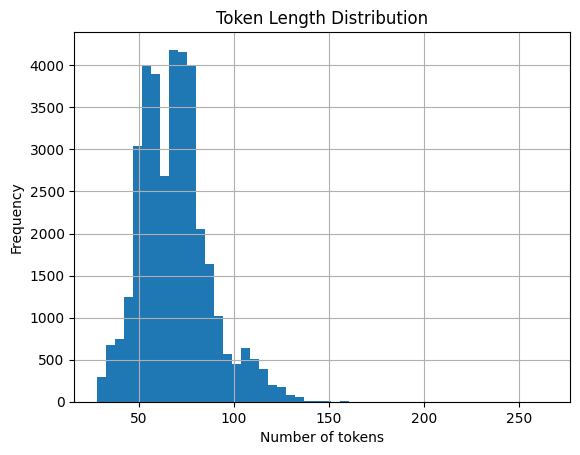

In [14]:
import matplotlib.pyplot as plt

lengths = [len(tokenizer.encode(t, truncation=False)) for t in df['text']]

plt.hist(lengths, bins=50)
plt.title('Token Length Distribution')
plt.xlabel("Number of tokens")
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [15]:
MAX_LEN = 256
lengths = [len(tokenizer.encode(text)) for text in df['text']]
L = (np.array(lengths) > MAX_LEN).sum()
print(f"There are {L} train samples(s) with more than {MAX_LEN} tokens")


There are 1 train samples(s) with more than 256 tokens


In [16]:
df.head(5)

,row_id,QuestionId,QuestionText,MC_Answer,StudentExplanation,Category,Misconception,target,label,is_correct,text
0,0,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),0ne third is equal to tree nineth,True_Correct,NA,True_Correct:NA,37,1.0,Question: What fraction of the shape is not sh...
1,1,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),1 / 3 because 6 over 9 is 2 thirds and 1 third...,True_Correct,NA,True_Correct:NA,37,1.0,Question: What fraction of the shape is not sh...
2,2,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),"1 3rd is half of 3 6th, so it is simplee to un...",True_Neither,NA,True_Neither:NA,64,1.0,Question: What fraction of the shape is not sh...
3,3,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),1 goes into everything and 3 goes into nine,True_Neither,NA,True_Neither:NA,64,1.0,Question: What fraction of the shape is not sh...
4,4,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),1 out of every 3 isn't coloured,True_Correct,NA,True_Correct:NA,37,1.0,Question: What fraction of the shape is not sh...


In [17]:
from sklearn.model_selection import train_test_split
from datasets import Dataset

counts = df['label'].value_counts()
rare = counts[counts < 2].index

rare_df = df[df['label'].isin(rare)]
rest_df = df[~df['label'].isin(rare)]

train_df, val_df = train_test_split(
    rest_df,
    test_size=0.15,
    stratify=rest_df['label'],
    random_state=42
)

# add rare samples back to training
train_df = pd.concat([train_df, rare_df])


COLS = ['text', 'label']
train_ds = Dataset.from_pandas(train_df[COLS])
val_ds = Dataset.from_pandas(val_df[COLS])

def tokenize(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=MAX_LEN)

train_ds = train_ds.map(tokenize, batched=True, remove_columns=['text'])
val_ds = val_ds.map(tokenize, batched=True, remove_columns=['text'])

columns = ['input_ids', 'attention_mask', 'label']
train_ds.set_format(type='torch', columns=columns)
val_ds.set_format(type='torch', columns=columns)


Map:   0%|          | 0/31192 [00:00<?, ? examples/s]

Map:   0%|          | 0/5504 [00:00<?, ? examples/s]

In [18]:
print(len(target_classes))

65


In [19]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    num_labels=len(target_classes),
    device_map='auto',
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    ignore_mismatched_sizes=True
)


2025-10-03 09:06:06.033438: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759482366.208776      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759482366.258798      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [20]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=['query_proj', 'value_proj', 'key_proj', 'dense'],  # DeBERTa modules
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_CLS  # Changed to sequence classification
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# Clear cache before training
torch.cuda.empty_cache()
gc.collect()


trainable params: 2,728,769 || all params: 187,200,898 || trainable%: 1.4577


30

In [21]:
def compute_map3(eval_pred):
    logits, labels = eval_pred
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()
    top3 = np.argsort(-probs, axis=1)[:, :3]  # Fixed: was top3 - instead of top3 =
    match = (top3 == labels[:, None])
    
    map3 = 0
    for i in range(len(labels)):
        if match[i, 0]:
            map3 += 1.0
        elif match[i, 1]:
            map3 += 1.0/2
        elif match[i, 2]:
            map3 += 1.0/3
    return {"map@3": map3 / len(labels)}
    

In [22]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

EPOCHS = 15 
DIR = f'/kaggle/working/ver_1'
os.makedirs(DIR, exist_ok=True)

training_args = TrainingArguments(
    output_dir=f'./{DIR}',
    do_train=True,
    do_eval=True,
    eval_strategy='steps',
    save_strategy='steps',
    num_train_epochs=EPOCHS,

    per_device_train_batch_size=64,
    per_device_eval_batch_size=128, 
    gradient_accumulation_steps=1, 
    learning_rate=3e-5,
    warmup_ratio = 0.1,
    lr_scheduler_type='cosine',
    weight_decay=0.01,

    logging_dir="./logs",
    logging_steps=25,
    save_steps=100,
    eval_steps=100,
    save_total_limit=1,

    metric_for_best_model='map@3',
    greater_is_better=True,
    load_best_model_at_end=True,

    report_to='none',
    bf16=True,  
    fp16=False,
    dataloader_pin_memory=False,
    remove_unused_columns=False,
    gradient_checkpointing=True,
    dataloader_num_workers = 2,

    max_grad_norm=1.0 # Gradient Clipping

)


In [23]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_map3,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

print("Starting training...")
try:
    trainer.train()
    print("\n" + "="*50)
    print("Training completed successfully!")
    print("="*50)
except Exception as e:
    print(f"Training failed with error: {e}")
    import traceback
    traceback.print_exc()

# Save the model
print("Saving model...")
trainer.save_model(f'{DIR}/final_model')
tokenizer.save_pretrained(f'{DIR}/final_model')

# Evaluate final performance
print("\nFinal evaluation:")
eval_results = trainer.evaluate()
print(eval_results)



No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Starting training...


Step,Training Loss,Validation Loss,Map@3
100,4.155500,4.151293,0.009508
200,4.121900,4.107884,0.009508
300,3.992100,3.950445,0.455911
400,3.677900,3.592707,0.540304
500,3.074700,2.926412,0.540304
600,2.424400,2.339662,0.540304
700,2.221200,2.246372,0.540304
800,2.196300,2.224575,0.540304
900,2.253500,2.213725,0.540304



Training completed successfully!
Saving model...

Final evaluation:


{'eval_loss': 3.5927066802978516, 'eval_map@3': 0.5403040213178332, 'eval_runtime': 73.6847, 'eval_samples_per_second': 74.697, 'eval_steps_per_second': 0.584, 'epoch': 1.8442622950819674}


In [29]:
import shutil
import os

# Define the directory you want to zip and the name for your zip file
source_dir = "/kaggle/working/final_model"
output_filename = "/kaggle/working/final_model_archive"

# Create the zip archive
# The first argument is the name of the output file (without extension).
# The second is the format ('zip' in this case).
# The third is the directory to zip.
shutil.make_archive(output_filename, 'zip', source_dir)

print(f"Zip file created at: {output_filename}.zip")

Zip file created at: /kaggle/working/final_model_archive.zip


In [24]:
trainer.save_model(f"./{DIR}/final_model")
print("Training completed successfully!")

Training completed successfully!


In [25]:
trainer.save_model("/kaggle/working/final_model")
tokenizer.save_pretrained("/kaggle/working/final_model")


('/kaggle/working/final_model/tokenizer_config.json',
 '/kaggle/working/final_model/special_tokens_map.json',
 '/kaggle/working/final_model/spm.model',
 '/kaggle/working/final_model/added_tokens.json',
 '/kaggle/working/final_model/tokenizer.json')

In [26]:
test = pd.read_csv('/kaggle/input/map-charting-student-math-misunderstandings/test.csv')
print(f"Test dataset shape: {test.shape}")
test.head()

Test dataset shape: (3, 5)


,row_id,QuestionId,QuestionText,MC_Answer,StudentExplanation
0,36696,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),"I think that 1/3 is the answer, as it's the si..."
1,36697,31772,What fraction of the shape is not shaded? Give...,\( \frac{3}{6} \),i think this answer is because 3 triangles are...
2,36698,32835,Which number is the greatest?,\( 6.2 \),because the 2 makes it higher than the others.


In [27]:
test = test.merge(correct, on=['QuestionId', 'MC_Answer'], how='left')
test['is_correct'] = test['is_correct'].fillna(0)

test['text'] = test.apply(format_input, axis=1)

ds_test = Dataset.from_pandas(test[['text']])
ds_test = ds_test.map(tokenize, batched=True, remove_columns=['text'])
ds_test.set_format(type='torch', columns=['input_ids', 'attention_mask'])

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

In [28]:
predictions = trainer.predict(ds_test)
probs = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=1).numpy()
top3 = np.argsort(-probs, axis=1)[:, :3] 

flat_top3 = top3.flatten()
decoded_labels = label_encoder.inverse_transform(flat_top3)  
top3_labels = decoded_labels.reshape(top3.shape)

joined_preds = [" ".join(row) for row in top3_labels]

sub = pd.DataFrame({
    "row_id": test.row_id.values,
    "Category:Misconception": joined_preds
})
sub.to_csv("submission.csv", index=False)
sub.to_csv("/kaggle/working/submission.csv", index=False)
print(sub.head())

   row_id                            Category:Misconception
0   36696  True_Correct:NA False_Neither:NA True_Neither:NA
1   36697  True_Correct:NA False_Neither:NA True_Neither:NA
2   36698  True_Correct:NA False_Neither:NA True_Neither:NA
